In [1]:
import numpy as np
import pandas as pd
import pykeen

In [2]:
kg = pd.read_csv("../knowledge-graphs/props_wikidata_movielens_small.csv")
kg.head()

,movieId,title,prop,obj,imdbId
0,199,The Umbrellas of Cherbourg,director,Jacques Demy,tt0058450
1,199,The Umbrellas of Cherbourg,screenwriter,Jacques Demy,tt0058450
2,199,The Umbrellas of Cherbourg,composer,Michel Legrand,tt0058450
3,199,The Umbrellas of Cherbourg,genre,drama,tt0058450
4,199,The Umbrellas of Cherbourg,genre,musical film,tt0058450


In [3]:
kg[['movieId', 'prop', 'obj']].astype(str).values

array([['199', 'director', 'Jacques Demy'],
       ['199', 'screenwriter', 'Jacques Demy'],
       ['199', 'composer', 'Michel Legrand'],
       ...,
       ['179053', 'country of origin', 'United States of America'],
       ['179053', 'narrative location', 'Los Angeles'],
       ['179053', 'title', '2048: Nowhere to Run']], dtype=object)

In [4]:
from pykeen.triples import TriplesFactory

tf = TriplesFactory.from_labeled_triples(triples=kg[['movieId', 'prop', 'obj']].astype(str).values)
train, validation, test = tf.split([0.8, 0.1, 0.1], random_state=42)

In [5]:
tf

TriplesFactory(num_entities=79008, num_relations=23, create_inverse_triples=False, num_triples=295700)

In [6]:
print(f'''Training Data: \t{train}''')
print(f'''Training Data: \t{validation}''')
print(f'''Test Data: \t{test}''')

Training Data: 	TriplesFactory(num_entities=79008, num_relations=23, create_inverse_triples=False, num_triples=236560)
Training Data: 	TriplesFactory(num_entities=79008, num_relations=23, create_inverse_triples=False, num_triples=29570)
Test Data: 	TriplesFactory(num_entities=79008, num_relations=23, create_inverse_triples=False, num_triples=29570)


In [7]:
print(train.num_triples + validation.num_triples + test.num_triples)
print(tf.num_triples)

295700
295700


In [8]:
from pykeen.pipeline import pipeline
from torch import nn

pipeline_result = pipeline(
    training=train,
    validation=validation,
    testing=test,
    model='Rotate',
    model_kwargs=dict(
        embedding_dim=128,
    ),
    optimizer='Adam',
    optimizer_kwargs=dict(lr=0.001),
    loss='NSSALoss',
    random_seed=42,
    device='cuda',
    negative_sampler='basic',
    negative_sampler_kwargs=dict(num_negs_per_pos=5, filtered=True),
    stopper='early',
    use_testing_data=False,
    stopper_kwargs=dict(frequency=5, patience=3, relative_delta=0.002,
                            metric='hits@5', larger_is_better=True),
    training_loop='sLCWA',
    training_kwargs=dict(num_epochs=50, batch_size=512),
)

Training epochs on cuda:0:   0%|          | 0/50 [00:00<?, ?epoch/s]

Training batches on cuda:0:   0%|          | 0.00/463 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0.00/463 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0.00/463 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0.00/463 [00:00<?, ?batch/s]

...

Training batches on cuda:0:   0%|          | 0.00/463 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0.00/463 [00:00<?, ?batch/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 409.58s seconds
INFO:pykeen.stoppers.early_stopping:New best result at epoch 50: 0.18151843084206967. Saved model weights to C:\Users\andre\.data\pykeen\checkpoints\best-model-weights-d31e303d-1620-410f-8ba3-29ae0bc42da1.pt
INFO:pykeen.training.training_loop:=> Saved checkpoint after having finished epoch 50.


Evaluating on cuda:0:   0%|          | 0.00/29.6k [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 410.33s seconds


<Axes: title={'center': 'Losses Plot'}, xlabel='Epoch', ylabel='nssa Loss'>

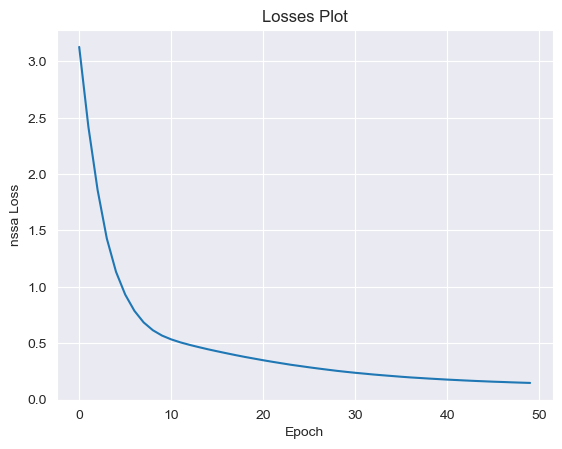

In [9]:
pipeline_result.plot_losses()

In [10]:
print(f"Hits@1: {pipeline_result.get_metric('hits@1')}")
print(f"Hits@3: {pipeline_result.get_metric('hits@3')}")
print(f"Hits@5: {pipeline_result.get_metric('hits@5')}")
print(f"Hits@10: {pipeline_result.get_metric('hits@10')}")
print(f"Mean Reciprocal Rank: {pipeline_result.get_metric('mean_reciprocal_rank')}")

Hits@1: 0.09707473791004397
Hits@3: 0.15185999323638824
Hits@5: 0.18151843084206967
Hits@10: 0.22556645248562732
Mean Reciprocal Rank: 0.14004500210285187


In [11]:
pipeline_result.model.entity_representations[0]

Embedding(
  (_embeddings): Embedding(79008, 256)
)

In [12]:
pipeline_result.save_to_directory("./exploration/models/rotate_v1")

INFO:pykeen.triples.triples_factory:Stored TriplesFactory(num_entities=79008, num_relations=23, create_inverse_triples=False, num_triples=236560) to file:///C:/Users/andre/Documents/Projetos_Git/list-aware-explanations/notebooks/exploration/models/rotate_v1/training_triples
INFO:pykeen.pipeline.api:Saved to directory: C:\Users\andre\Documents\Projetos_Git\list-aware-explanations\notebooks\exploration\models\rotate_v1


In [13]:
entity_embeds = pd.DataFrame(pipeline_result.model.entity_representations[0](indices=None).detach().cpu().numpy()).rename(
            tf.entity_id_to_label)
relation_embeds = pd.DataFrame(pipeline_result.model.relation_representations[0](indices=None).detach().cpu().numpy()).rename(
            tf.relation_id_to_label)

In [14]:
entity_embeds

,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
"""Crocodile"" Dundee",0.294853-0.848203j,0.104148+0.218382j,-0.006080-1.385300j,-0.104572+1.122772j,0.025732-0.242423j,-0.183773+0.001825j,-0.129265+0.017367j,0.005178+0.182788j,0.713825+0.021827j,-0.064172+0.032606j,...,-0.426621+1.248163j,-0.523775+0.156758j,-0.113093+0.142403j,0.883441-0.603103j,-0.068304-1.059908j,-0.249847-0.246956j,0.658979+0.043312j,0.063690+0.343846j,-0.290410-0.230862j,-0.037080+0.478558j
"""Crocodile"" Dundee II",-0.658148-0.431773j,0.627088+0.758085j,-0.402567+0.261229j,0.163611+0.204759j,-0.101787+1.076665j,-0.138650-0.433249j,-0.279160+0.918717j,-0.031431+0.052788j,0.873675-1.135881j,1.116533+0.885733j,...,0.305680-0.096467j,-0.892913-0.168085j,-0.465115+1.089206j,-0.386727+0.990879j,-0.613116+0.206706j,0.443937-0.104257j,-1.404141+0.085321j,-0.296299-0.978802j,-0.237311-0.308251j,0.429610-0.556921j
"""Home Alone"" house",0.008485+0.090147j,-0.442133-0.129802j,0.185561+0.209015j,-0.239058-0.452046j,-0.300680-0.635440j,0.162115+0.054910j,-0.232129-0.053266j,-0.485517-0.234776j,0.877516-0.402977j,0.784827-1.022883j,...,1.211363+0.034315j,0.320854+0.541757j,-0.775587-0.456743j,0.043868-0.207411j,-0.611718+0.024596j,0.568470+0.121129j,0.114038+0.587281j,0.327116+0.567129j,0.958862-0.484992j,-0.059373-0.064696j
"""Weird Al"" Yankovic",0.026474-0.255770j,-0.124254+0.766664j,-0.645801+0.550966j,0.000660-0.678000j,-0.065101-0.584480j,-0.479412-0.109989j,-0.000030-0.117587j,-0.577542-0.514862j,-0.458661+0.042682j,-0.780355+0.348987j,...,0.796012+0.084455j,-0.059318-0.870196j,0.660521+0.613989j,-0.339356-0.372652j,-0.146411+0.312678j,-0.007596-0.282252j,0.521266-0.458951j,-0.665529+0.291485j,0.387458-0.489747j,0.173695-0.604322j
'71,-0.710305+1.133792j,0.041001-0.005958j,0.085459-0.660997j,-0.276639-0.041581j,-1.218327+0.289525j,0.279596-0.616730j,-0.747072+0.679331j,-0.032896+0.305116j,-1.530805-0.356952j,0.123985+0.201192j,...,-0.019453-0.336171j,1.026238+1.018356j,-0.832378+0.057013j,0.691414+0.703778j,-0.637011-0.627872j,-0.018637-0.095645j,-1.279496+0.880115j,-0.335756+1.191040j,-0.344997+0.795474j,0.590197+0.169674j
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
태극기 휘날리며,0.351945-0.241795j,-0.085623-0.467460j,-0.942626-0.336558j,-0.141347+0.244151j,0.803607-0.605822j,1.235412-0.665131j,-0.221514+1.038200j,1.172157-1.096739j,-1.380345-0.330671j,-0.343464+0.175817j,...,-0.222970-0.237034j,-0.327967+0.343292j,0.012376-0.146108j,0.368140+0.081352j,0.100984-0.908978j,-0.796686-0.783165j,-0.398285-1.203018j,0.762405+0.046440j,0.020822-0.149715j,-0.652973-0.587092j
플란다스의 개,0.585709-0.098069j,-1.262560+0.359272j,0.660259+0.966465j,-1.340771+0.395479j,-0.630669+0.004348j,-0.567714-0.475084j,-0.579459-0.183217j,0.529116-0.026717j,-0.159808-0.841850j,-0.068656+0.050053j,...,-0.023958-1.006974j,1.244798-0.370747j,0.384884+0.072533j,-0.207447+0.117652j,-1.484721-0.879228j,-0.315398-0.061556j,-0.086686-1.192815j,0.040257-0.079653j,1.184791+0.008401j,-0.098638+0.144771j
화산고,-0.640570+0.046250j,-0.118159-0.060403j,-0.935726-0.488042j,1.227579+0.867089j,-1.274480+0.252382j,0.119290-0.419530j,0.022538-0.009380j,0.783364+0.456186j,-0.379779+1.017160j,0.107981-0.707761j,...,-0.260984-0.208401j,0.294879+1.507661j,-1.556204+0.055375j,-0.635422+1.058071j,-0.224723+1.203637j,0.140999-0.333717j,-1.095219+0.246690j,0.319539+1.466670j,-0.585931-1.308115j,0.051837-0.017801j
활,-0.575544-0.886745j,-0.796295-0.334967j,0.561178+0.043009j,0.160315-0.602872j,0.990594-0.146244j,-0.853105-1.174397j,-0.870698+0.078146j,1.220700-1.227646j,1.380258-0.419335j,-0.429723+0.453233j,...,0.971461+0.323118j,-0.251715+0.512588j,0.388779+0.204305j,0.334091-0.360549j,0.122447+0.265465j,-0.014983-0.285153j,-0.762190-0.798270j,-0.902316+0.067608j,1.072631+0.146485j,0.204087+0.154998j


In [15]:
relation_embeds

,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
award received,-0.984312-0.176435j,-0.241347+0.970439j,0.570652+0.821192j,-0.813105+0.582117j,-0.105629+0.994406j,-0.295658-0.955294j,-0.100548-0.994932j,-0.776353+0.630298j,-0.993833-0.110885j,-0.998812+0.048740j,...,0.707184-0.707029j,-0.698034-0.716064j,-0.936741-0.350024j,-0.667603+0.744518j,0.994914+0.100725j,-0.698586-0.715526j,-0.160753+0.986995j,0.600317+0.799762j,-0.919766+0.392467j,-0.790612-0.612317j
cast member,0.658241+0.752807j,-0.867538+0.497371j,0.384457-0.923143j,-0.857478+0.514520j,-0.771587-0.636124j,0.489658+0.871915j,0.491465-0.870897j,0.482110+0.876111j,-0.902611-0.430456j,-0.823848-0.566811j,...,-0.681340-0.731967j,0.566509-0.824055j,-0.753191+0.657802j,0.513378-0.858162j,-0.876756+0.480935j,0.657191-0.753724j,-0.863166-0.504921j,-0.865880-0.500252j,-0.886758-0.462234j,-0.887311-0.461172j
composer,0.543707+0.839275j,0.501418+0.865205j,0.410686+0.911777j,0.542826-0.839845j,-0.783125-0.621865j,-0.681235+0.732065j,-0.634960+0.772545j,-0.600148+0.799889j,0.534835-0.844957j,0.566080+0.824350j,...,0.704505-0.709699j,-0.506818+0.862053j,-0.782569+0.622564j,0.509810-0.860287j,-0.736843+0.676064j,-0.787930+0.615765j,-0.779892-0.625914j,0.754554-0.656238j,-0.796638-0.604457j,-0.901295-0.433206j
costume designer,-0.907417+0.420231j,0.743551-0.668679j,-0.723476-0.690350j,0.879961+0.475046j,0.494173+0.869364j,0.810577-0.585632j,0.575697+0.817663j,0.650691-0.759342j,-0.629382+0.777096j,0.428561+0.903513j,...,0.526033-0.850464j,-0.527637+0.849470j,-0.759046+0.651037j,-0.827124+0.562019j,0.610137-0.792296j,-0.658383-0.752683j,0.515535-0.856869j,-0.802378-0.596816j,0.582542-0.812801j,-0.773065+0.634327j
country of origin,0.742578+0.669760j,0.692595+0.721327j,-0.603069+0.797689j,-0.717780+0.696270j,-0.880815-0.473461j,-0.874802+0.484480j,0.770821-0.637052j,0.638413-0.769694j,0.735101+0.677957j,-0.730741-0.682655j,...,-0.696324-0.717728j,0.678268-0.734814j,0.679153+0.733997j,0.681807+0.731532j,0.627283+0.778792j,-0.650650-0.759378j,0.884398-0.466733j,-0.476854+0.878982j,0.716347+0.697745j,0.713325+0.700834j
creator,-0.300247-0.953861j,0.056520+0.998401j,-0.402353+0.915485j,-0.781510+0.623893j,-0.526202-0.850360j,-0.765651+0.643257j,-0.629952-0.776634j,0.680699+0.732563j,-0.387994-0.921662j,0.526268-0.850319j,...,-0.786735+0.617292j,0.317333-0.948314j,-0.662959-0.748656j,0.773445-0.633863j,0.987634-0.156774j,0.583829-0.811877j,-0.975444+0.220248j,-0.514837+0.857288j,-0.923030+0.384729j,0.950689-0.310146j
director,0.977519-0.210845j,0.995916-0.090289j,-0.983491+0.180960j,-0.881431+0.472313j,-0.136446-0.990648j,0.406123+0.913818j,-0.793776-0.608211j,0.999825-0.018686j,-0.996811-0.079798j,0.959655+0.281179j,...,0.416912-0.908947j,0.701052-0.713110j,-0.757989+0.652267j,0.527918-0.849295j,-0.317685-0.948196j,-0.965438-0.260634j,-0.609189-0.793025j,-0.998140-0.060970j,-0.710298+0.703901j,-0.066368+0.997795j
director of photography,-0.717979-0.696064j,-0.784712-0.619861j,-0.900541-0.434771j,-0.807999+0.589184j,-0.732689+0.680564j,-0.808975-0.587844j,0.621101+0.783730j,-0.603912-0.797051j,-0.729882+0.683573j,0.734392-0.678725j,...,-0.530225-0.847857j,0.700972-0.713189j,0.618003-0.786176j,-0.739328-0.673345j,-0.518947-0.854807j,0.682009-0.731344j,-0.782085-0.623172j,0.352626-0.935764j,0.530478+0.847699j,0.642940-0.765916j
executive producer,-0.412332+0.911034j,-0.972251-0.233940j,-0.355808-0.934559j,-0.622642+0.782507j,-0.346144-0.938181j,0.878210-0.478276j,0.923618-0.383314j,0.637749+0.770244j,0.845825-0.533461j,0.822835+0.568280j,...,-0.701251-0.712914j,0.999100+0.042417j,-0.689219+0.724553j,-0.932161+0.362044j,0.331733-0.943373j,0.710941+0.703252j,-0.363457-0.931611j,-0.606767+0.794880j,-0.486414+0.873729j,0.701649-0.712523j
film editor,0.755183-0.655514j,-0.772450+0.635075j,-0.918475-0.395478j,0.543181-0.839616j,-0.824275+0.566189j,0.509283+0.860599j,-0.777856+0.628442j,0.657283+0.753644j,-0.824895-0.565286j,0.652752-0.757572j,...,0.731269-0.682090j,0.620221-0.7844

In [16]:
entity_embeds.loc['drama'].to_numpy()

array([-0.17897388+0.33526868j,  0.03945707-0.01192901j,
       -0.2883971 +0.3252246j , -0.329138  +0.8448741j ,
       -0.19294539-0.23776571j, -0.5034996 -0.2394773j ,
        0.24744654-0.0859008j ,  0.298427  +0.39547908j,
       -0.09981995+0.1558637j , -0.08765486+0.48110232j,
        0.19672512-0.24858211j,  0.5196442 -0.33304852j,
        0.0109252 -0.28021634j,  0.3161124 -0.20387998j,
       -0.15875368+0.02997127j, -0.55531126-0.29071584j,
        0.3210921 +0.41042313j,  0.12567282+1.0718484j ,
        0.67106915+0.4596421j ,  0.10011443-0.22726426j,
       -0.1812234 -0.20994678j, -0.32422572+0.23304735j,
       -0.3223663 +0.05992511j,  0.04755876-0.24639213j,
        0.2484736 -0.1752959j , -0.0052103 +0.05275133j,
       -0.08059839+0.26204574j, -0.01532424+0.11864011j,
        0.3885599 -0.5001472j ,  0.13883083-0.32192543j,
        0.44155928-0.00667321j, -0.11514226+0.04806411j,
       -0.1763538 -0.42150038j, -0.11187687+0.16863751j,
       -0.00412144-0.19802146j,

In [17]:
entity_embeds.index

Index(['"Crocodile" Dundee', '"Crocodile" Dundee II', '"Home Alone" house',
       '"Weird Al" Yankovic', ''71', ''A' gai wak', ''Til There Was You',
       ''night, Mother', '(500) Days of Summer', '...All the Marbles',
       ...
       '장화, 홍련', '조용한 가족', '좋은 놈, 나쁜 놈, 이상한 놈', '추격자', '친절한 금자씨', '태극기 휘날리며',
       '플란다스의 개', '화산고', '활', '황해'],
      dtype='object', length=79008)

In [18]:
import numpy as np
import pandas as pd

def cosine_similarity_complex_df(df: pd.DataFrame, entity: str, n=20) -> pd.DataFrame:
    """
    Compute pairwise cosine similarity for complex embeddings in a DataFrame.
    Rows = embeddings, columns = features.
    Returns a DataFrame with pairwise similarities.
    """
    sim_dict = {} 
    entity_embed = df.loc[entity].to_numpy()

    for i in df.index:
        other_embed = df.loc[i].to_numpy()
        # Cosine similarity for complex vectors
        sim = np.abs(np.vdot(entity_embed, other_embed)) / (np.linalg.norm(entity_embed) * np.linalg.norm(other_embed))
        sim_dict[i] = sim

    sim_dict = dict(sorted(sim_dict.items(), key=lambda item: item[1], reverse=True))
    sorted_dict = {k: sim_dict[k] for k in list(sim_dict)[:n]}
    return sorted_dict

In [19]:
cosine_similarity_complex_df(entity_embeds, 'drama')

{'drama': 1.0000001,
 'romance film': 0.8827375,
 'biographical film': 0.7932715,
 'crime film': 0.78830975,
 'film based on a novel': 0.7689138,
 'film based on literature': 0.7462492,
 'war film': 0.74197423,
 'coming-of-age story': 0.73140025,
 'erotic film': 0.7183574,
 'film based on books': 0.71206397,
 'LGBT-related film': 0.7006428,
 'trial film': 0.69855255,
 'comedy-drama': 0.6969231,
 'prison film': 0.68650794,
 'mystery film': 0.6845611,
 'neo-noir': 0.6835431,
 'erotic thriller': 0.6810638,
 'historical film': 0.67182356,
 'political thriller': 0.6697358,
 'art film': 0.65858716}

In [20]:
cosine_similarity_complex_df(entity_embeds, 'Leonardo DiCaprio')

{'Leonardo DiCaprio': 1.0,
 'Matt Damon': 0.5691457,
 'Richard Riehle': 0.54534376,
 'Tobey MaguireA': 0.5362847,
 'George Clooney': 0.52818215,
 'Mark Boone Junior': 0.52814215,
 'Robert Downey Jr.': 0.52677846,
 'Owen Wilson': 0.52575344,
 'Brad Pitt': 0.5255241,
 'Gene Hackman': 0.52427703,
 'Philip Seymour Hoffman': 0.52344304,
 'Bruce Willis': 0.5229535,
 'Allen Garfield': 0.519265,
 'Steve Buscemi': 0.5179748,
 'Danny DeVito': 0.5143584,
 'Robin Williams': 0.5115453,
 'Dan Aykroyd': 0.50956714,
 'Arnold Schwarzenegger': 0.5095354,
 'Michael Douglas': 0.50919133,
 'Catherine Curtin': 0.5085921}

In [21]:
cosine_similarity_complex_df(entity_embeds, 'Brad Pitt')

{'Brad Pitt': 1.0000001,
 'Matt Damon': 0.6008228,
 'Ben Affleck': 0.57362336,
 'Nicolas Cage': 0.54635715,
 'George Clooney': 0.54121476,
 'John Malkovich': 0.5409193,
 'Kevin Spacey': 0.53962904,
 'Ann Dowd': 0.53930867,
 'Russell Crowe': 0.5379236,
 'Sean Penn': 0.535225,
 'Robert De Niro': 0.5314631,
 'Cameron Diaz': 0.53099823,
 'Kevin Costner': 0.5304539,
 'Tom Cruise': 0.52959555,
 'Danny DeVito': 0.52558106,
 'Leonardo DiCaprio': 0.5255241,
 'Owen Wilson': 0.5250951,
 'Marky stankypoo': 0.52395767,
 'John Cusack': 0.52102274,
 'Robin Wright': 0.52062786}

In [22]:
cosine_similarity_complex_df(entity_embeds, 'Batman Begins')

{'Batman Begins': 1.0000001,
 'The Devil Wears Prada': 0.3271859,
 '90600': 0.3163424,
 'Patriot Games': 0.30905864,
 'The Saint': 0.30628633,
 'True Romance': 0.30583486,
 'Jarhead': 0.30576658,
 'The Pelican Brief': 0.30113217,
 'Malcolm X': 0.30038795,
 'Cop Out': 0.2989462,
 'Torque': 0.29482257,
 'Rocky V': 0.29285136,
 'The Accused': 0.2912421,
 'The Cobbler': 0.2900155,
 'Me Him Her': 0.2892036,
 'Darkest Hour': 0.28751615,
 'Reginald Harkema': 0.2870955,
 '2899': 0.28691998,
 'The Great Santini': 0.28604457,
 'Three Men and a Baby': 0.28582686}

In [23]:
cosine_similarity_complex_df(entity_embeds, 'Titanic')

{'Titanic': 0.99999994,
 'Somebody to Love': 0.35592356,
 'Little Women': 0.34104547,
 'Finding Neverland': 0.33684993,
 'Sin City': 0.32943207,
 'The Lord of the Rings: The Two Towers': 0.32861173,
 'Bright Lights, Big City': 0.3267411,
 'Gladiator': 0.32607877,
 'The Karate Kid': 0.32598785,
 'The Abyss': 0.3236713,
 'Strange Days': 0.32215884,
 'Rain Man': 0.32157657,
 'The Lord of the Rings: The Return of the King': 0.320833,
 'The World Is Not Enough': 0.3206243,
 'Focus': 0.3187606,
 'Hope Springs': 0.31872404,
 'The Boxer': 0.31488648,
 'District 9': 0.30871078,
 'An Officer and a Gentleman': 0.30841842,
 'The Man from Elysian Fields': 0.30666852}

In [24]:
cosine_similarity_complex_df(entity_embeds, 'Bill Conti')

{'Bill Conti': 1.0,
 'Carter Burwell': 0.5642999,
 'Alan Silvestri': 0.55595386,
 'James Horner': 0.548555,
 'James Newton Howard': 0.54635674,
 'Dave Grusin': 0.5403758,
 'Basil Poledouris': 0.5389759,
 'Thomas Newman': 0.53652287,
 'Jerry Goldsmith': 0.5288617,
 'Lalo Schifrin': 0.5212378,
 'Jack Nitzsche': 0.5175005,
 'Christopher Young': 0.51144224,
 'Brad Fiedel': 0.5102474,
 'Marco Beltrami': 0.5087795,
 'John Williams': 0.507852,
 'Elmer Bernstein': 0.5019314,
 'Michael Convertino': 0.5015223,
 'Danny Elfman': 0.49700043,
 'Marvin Hamlisch': 0.49508724,
 'Mychael Danna': 0.49237305}

In [25]:
cosine_similarity_complex_df(entity_embeds, 'Home Alone')

{'Home Alone': 0.99999994,
 'Jimmy Neutron: Boy Genius': 0.28864944,
 "Weekend at Bernie's": 0.28288662,
 'Mr. Peabody & Sherman': 0.27926663,
 'Jacky Cheung': 0.2747607,
 'Nathanaël Karmitz': 0.27365205,
 'Batman': 0.2712065,
 'Deborah Kerr': 0.2684564,
 'When a Stranger Calls': 0.26815137,
 'Lyrick Studios': 0.26767185,
 'Hiroki Narimiya': 0.2666259,
 'Psycho tetralogy': 0.26466444,
 'Hal K. Dawson': 0.26311097,
 'Louise Fazenda': 0.26276907,
 'Charlotte Frogner': 0.2620589,
 'Horrible Bosses': 0.25762287,
 'Home Alone 2: Lost in New York': 0.25591174,
 'Aki Kaurismäki': 0.25565243,
 'Kenji Matsuda': 0.25492823,
 'Sterling Hayden': 0.25485808}

In [26]:
cosine_similarity_complex_df(entity_embeds, 'Steven Spielberg')

{'Steven Spielberg': 0.99999994,
 'Kathleen Kennedy': 0.7039353,
 'Frank Marshall': 0.6594215,
 'Robert Zemeckis': 0.59244853,
 'Scott Rudin': 0.58640176,
 'Ridley Scott': 0.58529454,
 'Francis Ford Coppola': 0.5642306,
 'Richard Donner': 0.5557458,
 'Tim Burton': 0.5409382,
 'Colin Wilson': 0.5392254,
 'Gary Levinsohn': 0.5305139,
 'Alan J. Pakula': 0.52941966,
 'Mario Kassar': 0.5253641,
 'Joel Coen': 0.52269053,
 'George Lucas': 0.51980346,
 'Harvey Weinstein': 0.5116816,
 'Walter F. Parkes': 0.5108986,
 'Martin Scorsese': 0.510327,
 'Ethan Coen': 0.5094409,
 'John McTiernan': 0.5090331}

In [27]:
import torch

my_pykeen_model = torch.load("./exploration/models/rotate_v1/trained_model.pkl")

In [28]:
load_entity_embeds = pd.DataFrame(my_pykeen_model.entity_representations[0](indices=None).detach().cpu().numpy()).rename(
            tf.entity_id_to_label)

In [29]:
load_entity_embeds

,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
"""Crocodile"" Dundee",0.294853-0.848203j,0.104148+0.218382j,-0.006080-1.385300j,-0.104572+1.122772j,0.025732-0.242423j,-0.183773+0.001825j,-0.129265+0.017367j,0.005178+0.182788j,0.713825+0.021827j,-0.064172+0.032606j,...,-0.426621+1.248163j,-0.523775+0.156758j,-0.113093+0.142403j,0.883441-0.603103j,-0.068304-1.059908j,-0.249847-0.246956j,0.658979+0.043312j,0.063690+0.343846j,-0.290410-0.230862j,-0.037080+0.478558j
"""Crocodile"" Dundee II",-0.658148-0.431773j,0.627088+0.758085j,-0.402567+0.261229j,0.163611+0.204759j,-0.101787+1.076665j,-0.138650-0.433249j,-0.279160+0.918717j,-0.031431+0.052788j,0.873675-1.135881j,1.116533+0.885733j,...,0.305680-0.096467j,-0.892913-0.168085j,-0.465115+1.089206j,-0.386727+0.990879j,-0.613116+0.206706j,0.443937-0.104257j,-1.404141+0.085321j,-0.296299-0.978802j,-0.237311-0.308251j,0.429610-0.556921j
"""Home Alone"" house",0.008485+0.090147j,-0.442133-0.129802j,0.185561+0.209015j,-0.239058-0.452046j,-0.300680-0.635440j,0.162115+0.054910j,-0.232129-0.053266j,-0.485517-0.234776j,0.877516-0.402977j,0.784827-1.022883j,...,1.211363+0.034315j,0.320854+0.541757j,-0.775587-0.456743j,0.043868-0.207411j,-0.611718+0.024596j,0.568470+0.121129j,0.114038+0.587281j,0.327116+0.567129j,0.958862-0.484992j,-0.059373-0.064696j
"""Weird Al"" Yankovic",0.026474-0.255770j,-0.124254+0.766664j,-0.645801+0.550966j,0.000660-0.678000j,-0.065101-0.584480j,-0.479412-0.109989j,-0.000030-0.117587j,-0.577542-0.514862j,-0.458661+0.042682j,-0.780355+0.348987j,...,0.796012+0.084455j,-0.059318-0.870196j,0.660521+0.613989j,-0.339356-0.372652j,-0.146411+0.312678j,-0.007596-0.282252j,0.521266-0.458951j,-0.665529+0.291485j,0.387458-0.489747j,0.173695-0.604322j
'71,-0.710305+1.133792j,0.041001-0.005958j,0.085459-0.660997j,-0.276639-0.041581j,-1.218327+0.289525j,0.279596-0.616730j,-0.747072+0.679331j,-0.032896+0.305116j,-1.530805-0.356952j,0.123985+0.201192j,...,-0.019453-0.336171j,1.026238+1.018356j,-0.832378+0.057013j,0.691414+0.703778j,-0.637011-0.627872j,-0.018637-0.095645j,-1.279496+0.880115j,-0.335756+1.191040j,-0.344997+0.795474j,0.590197+0.169674j
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
태극기 휘날리며,0.351945-0.241795j,-0.085623-0.467460j,-0.942626-0.336558j,-0.141347+0.244151j,0.803607-0.605822j,1.235412-0.665131j,-0.221514+1.038200j,1.172157-1.096739j,-1.380345-0.330671j,-0.343464+0.175817j,...,-0.222970-0.237034j,-0.327967+0.343292j,0.012376-0.146108j,0.368140+0.081352j,0.100984-0.908978j,-0.796686-0.783165j,-0.398285-1.203018j,0.762405+0.046440j,0.020822-0.149715j,-0.652973-0.587092j
플란다스의 개,0.585709-0.098069j,-1.262560+0.359272j,0.660259+0.966465j,-1.340771+0.395479j,-0.630669+0.004348j,-0.567714-0.475084j,-0.579459-0.183217j,0.529116-0.026717j,-0.159808-0.841850j,-0.068656+0.050053j,...,-0.023958-1.006974j,1.244798-0.370747j,0.384884+0.072533j,-0.207447+0.117652j,-1.484721-0.879228j,-0.315398-0.061556j,-0.086686-1.192815j,0.040257-0.079653j,1.184791+0.008401j,-0.098638+0.144771j
화산고,-0.640570+0.046250j,-0.118159-0.060403j,-0.935726-0.488042j,1.227579+0.867089j,-1.274480+0.252382j,0.119290-0.419530j,0.022538-0.009380j,0.783364+0.456186j,-0.379779+1.017160j,0.107981-0.707761j,...,-0.260984-0.208401j,0.294879+1.507661j,-1.556204+0.055375j,-0.635422+1.058071j,-0.224723+1.203637j,0.140999-0.333717j,-1.095219+0.246690j,0.319539+1.466670j,-0.585931-1.308115j,0.051837-0.017801j
활,-0.575544-0.886745j,-0.796295-0.334967j,0.561178+0.043009j,0.160315-0.602872j,0.990594-0.146244j,-0.853105-1.174397j,-0.870698+0.078146j,1.220700-1.227646j,1.380258-0.419335j,-0.429723+0.453233j,...,0.971461+0.323118j,-0.251715+0.512588j,0.388779+0.204305j,0.334091-0.360549j,0.122447+0.265465j,-0.014983-0.285153j,-0.762190-0.798270j,-0.902316+0.067608j,1.072631+0.146485j,0.204087+0.154998j


In [30]:
cosine_similarity_complex_df(load_entity_embeds, 'Steven Spielberg')

{'Steven Spielberg': 0.99999994,
 'Kathleen Kennedy': 0.7039353,
 'Frank Marshall': 0.6594215,
 'Robert Zemeckis': 0.59244853,
 'Scott Rudin': 0.58640176,
 'Ridley Scott': 0.58529454,
 'Francis Ford Coppola': 0.5642306,
 'Richard Donner': 0.5557458,
 'Tim Burton': 0.5409382,
 'Colin Wilson': 0.5392254,
 'Gary Levinsohn': 0.5305139,
 'Alan J. Pakula': 0.52941966,
 'Mario Kassar': 0.5253641,
 'Joel Coen': 0.52269053,
 'George Lucas': 0.51980346,
 'Harvey Weinstein': 0.5116816,
 'Walter F. Parkes': 0.5108986,
 'Martin Scorsese': 0.510327,
 'Ethan Coen': 0.5094409,
 'John McTiernan': 0.5090331}